# Test Signal for Initial Synchronization

This notebook synthesizes a test signal for initial synchronization. The generated signal includes a known preamble and a payload of random bits for testing the synchronization algorithms.

The channel introduces a delay, amplitude and phase changes, a constant frequency offset, and additive noise.

In [1]:
## Boilerplate instructions for importing NumPy and Matplotlib
# Import NumPy
import numpy as np

import matplotlib.pyplot as plt
%matplotlib inline

import seaborn as sns
sns_context = "notebook"
sns.set_theme(context=sns_context, style="ticks")

# proper labeling of plots
from matplotlib.ticker import EngFormatter

In [2]:
from dc_632_26.sources import RandomBitSource
from dc_632_26.pulses import SqrtRaisedCosinePulse
from dc_632_26.constellations import standard_constellation
from dc_632_26.modulation import modulation
from dc_632_26.pulse_shaper import PulseShaper
from dc_632_26.estimator import Estimator
from dc_632_26.detector import ThresholdDetector
#from dc_632_26.demodulation import Slicer
from dc_632_26.demodulation import GenericSlicer


## Transmitted Signal

**Notes:**
- The transmitted signal consists of a known training sequence (preamble) followed by a payload of random bits.
- SRRC pulse shaping is used for both the training sequence and the payload.
- The preamble is BPSK modulated, the payload is QPSK modulated
- The signal is oversampled 32 times per symbol period to enable fractional delays; it will be reduced to 8x oversampling during channel simulation.

In [3]:
## Signal parameters
# preamble - this is a length 31 M-sequence
preamble_bits = np.array([1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 
                          0, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 
                          1, 1, 0, 1, 0], dtype=np.uint8)
preamble_constellation = standard_constellation.BPSK
preamble_symbols = modulation(preamble_bits, preamble_constellation)

# payload - 1000 random bits
payload_bits = RandomBitSource().get_bits(1000)
payload_constellation = standard_constellation.QPSK
payload_symbols = modulation(payload_bits, payload_constellation)

# pulse shaping
fsT = 32
pulse = SqrtRaisedCosinePulse(num_samples=10*fsT, oversamp=fsT, alpha=0.5)
ps = PulseShaper(pulse, fsT)

bb_sig = ps.generate_waveform(np.concatenate((preamble_symbols, payload_symbols)))



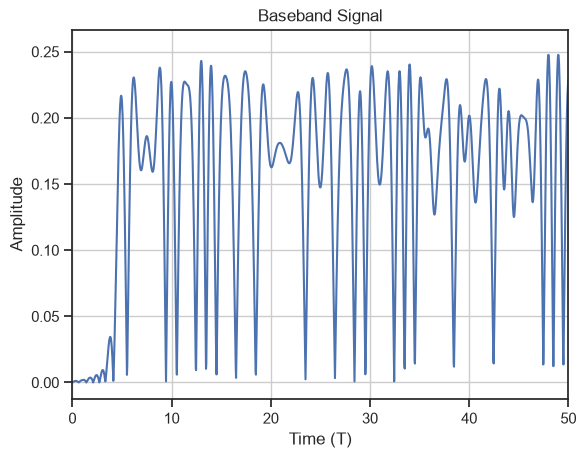

In [4]:
plt.plot(np.arange(len(bb_sig))/fsT, np.abs(bb_sig))
plt.xlabel('Time (T)')
plt.ylabel('Amplitude')
plt.title('Baseband Signal')
plt.grid(True)
plt.xlim(0, 50)
plt.show()

## Simulating transmission

Our simulated transmission will include:

* AWGN
* a delay of 102 samples
* amplitude and phase change
* reduction of the sample rate from 32 to 8; note that 102 is not evenly divisible by 8 so that we incur a fractional delay
* frequency offset is not simulated at this time

In [5]:
## channel parameters
delay_samples = 102
ds_factor = 4       # down-sample by 4
fsT_r = fsT // ds_factor

# frequency offset per sample, phase change is 0.1*2*pi over course of preamble
df = 0.1/(len(preamble_symbols) * fsT) 
X = .5*np.exp(1j*np.pi/4) # amplitude and phase
#adjust
# df = 0.1/(len(preamble_symbols) * fsT) 
# X = 1.*np.exp(1j*0*np.pi/4) # amplitude and phase

# delay by pre-pending zeros
rr = np.concatenate(( np.zeros(delay_samples), 
                     X * bb_sig * np.exp(2j * np.pi * df * np.arange(len(bb_sig))), 
                     np.zeros(delay_samples) ))

# down-sample
rr = rr[::ds_factor]
fsT_r = fsT // ds_factor

SNR_dB = 40
SNR = 10**(SNR_dB/10)
noise_var = preamble_constellation.Es / SNR 

## the down-sampled signal amplitude is increased, to compensate for "energy" lost
# when discarding samples
rr = np.sqrt(ds_factor)*rr + np.sqrt(0.5 * noise_var) * (np.random.randn(len(rr)) + 1j*np.random.randn(len(rr))) 

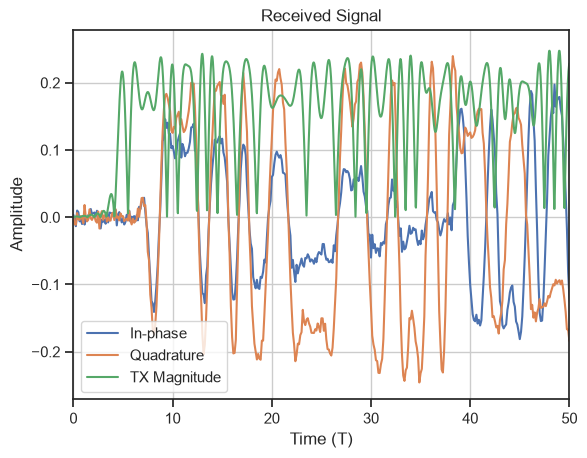

In [6]:
plt.plot(np.arange(len(rr))/fsT_r, rr.real, label="In-phase")
plt.plot(np.arange(len(rr))/fsT_r, rr.imag, label="Quadrature")
plt.plot(np.arange((len(bb_sig)))/fsT, 
         np.abs(bb_sig), label="TX Magnitude")

plt.xlabel('Time (T)')
plt.ylabel('Amplitude')
plt.title('Received Signal')
plt.xlim(0, 50)
plt.grid(True)
plt.legend(loc='lower left')
plt.show()

For reference: With the above parameters, the first sample of the preamble is the 25-th or 26-th (102/4) sample of the received signal. 

## Receiver Processing

The goal is to develop a full receiver that can accurately detect and synchronize with the preamble of the received signal, and subsequently demodulate the transmitted data. To help this goal, the `PolyPhaseCorrelator` class below computes all quantities necessary for detecting the preamble and determining the optimal sampling phase. Note that this correlator assumes that the received signal is passed through a pulse matched filter.

The remaining tasks to complete the receiver include:
- Implementing the preamble detection logic using the output of the `PolyPhaseCorrelator`. This involves replacing the peak search over the entire signal with detection using a suitably chosen threshold. This process should account for the (likely) case that the first breach of the threshold does not correspond to the peak of the correlator output; that is likely to occur a few samples after the first breach. The detection logic should output:
    + the estimated sampling phase
    + the estimated symbol index of the preamble peak
    + the correlator output at the detected preamble peak
- Estimation of additional channel parameters once the preamble has been detected, including:
    + the channel complex gain (amplitude and phase)
    + the frequency offset (be explicit, if this is estimated in Hz or as normalized frequency. For a normalized frequency, there are two options: cycles per sample or cycles per symbol)
    + the noise variance (at the matched filter output)
- Applying the estimated channel parameters to the received signal for proper synchronization. Upon detection of the preamble and estimation of the channel parameters, the receiver must correct the received signal to compensate these channel effects.
    + Note: determining the correct phase requires a little thought, as it depends on the phase of the channel complex gain, the frequency offset, and the delays introduced by channel and matched filter.
- Demodulating the received data symbols after synchronization. The correct phase of the matched filter outputs, with corrected amplitude frequency and phase, must be demodulated starting with the first symbol after the preamble.

Ultimately, all of these pieces should be integrated into a complete receiver chain; that is probably best realized as a single class. It should:
* toggle between two states:
    + preamble detection and synchronization
    + data demodulation
* at the transition from synchronization to data demodulation, the various parameter estimates should be computed
* estimates of the channel parameters (complex gain, frequency offset, noise variance) should be used to correct the received signal before demodulation
* the correct samples must be fed to the demodulator: correct first sample and correct sampling phase
* after demodulation, the receiver transitions back to the preamble detection and synchronization state for the next frame. At the transition, the correlator is reset.

**Hint:** In the received signal, the preamble starts at the 26-th sample. Probably more importantly, after the signal is passed through the matched filter, the first sample of the preamble is the 105-th sample of the matched filter output. The first sample of the data is the 353-rd sample of the matched filter output (105 + 31*8 = 353). 

You can use this information: 
* to verify the correctness of your preamble detection and synchronization logic and 
* to develop and test the estimation of the channel parameters. 
* Even the demodulation process can leverage this information to locate the start of the data symbols.

In [7]:
class PolyPhaseCorrelator:
    """Sequential Polyphase Correlator for signal synchronization.
    
    This class implements a sequential polyphase correlator for signal synchronization. It 
    processes the output of the (pulse) matched filter and computes the correlation with the known preamble sequence for each sampling phase. Sequential processing means that the correlator updates its output sample by sample, rather than computing the correlation over the entire signal at once. This enables real-time synchronization and permits transitioning to demodulation as soon as synchronization is achieved.

    Attributes:
    -----------
    preamble_symbols : np.ndarray
        The known preamble sequence used for correlation.
    num_phases : int
        The number of sampling phases for the polyphase correlator; this equals the oversampling factor of the received signal.
    n_phase : int
        The current sampling phase index.
    n_symbol : int
        The current symbol index.

    Methods:
    --------
    __init__(preamble_symbols, num_phases)
        Initialize the correlator with the given preamble and number of phases.
    reset()
        Reset the internal state of the correlator.
    update(matched_filter_output)
        Update the correlator with a new matched filter output sample and return the correlation and norm-squared.
    correlate()
        Compute the correlation for the current buffer state.
    sq_magnitude_mf_out()
        Compute the norm-squared of the matched filter outputs for the current phase.
    buffer(n_phase):
        Return the last `len(preamble_symbols)` samples for the specified phase, starting with the oldest sample.
    
    """
    def __init__(self, preamble_symbols, num_phases):
        self.preamble_symbols = preamble_symbols
        self.num_phases = num_phases

        ## internal state
        # ring buffer for each phase; stores the last `len(preamble_symbols)` samples
        self._buffer = np.zeros((num_phases, len(preamble_symbols)), dtype=complex)
        self.n_phase = -1
        self.n_symbol = -1

    def __repr__(self):
        return f"PolyPhaseCorrelator(preamble_symbols={self.preamble_symbols}, num_phases={self.num_phases})"

    def reset(self):
        """Reset the internal buffers of the correlator.
        
        Resets the internal state of the correlator, including the buffer, phase, and symbol counters. Invoke this function before starting a new synchronization process.
        """
        self._buffer.fill(0)
        self.n_phase = -1
        self.n_symbol = -1

    def update(self, matched_filter_output):
        """Update the inner state of the correlator with a new matched filter output sample.

        Parameters:
        -----------
        matched_filter_output : complex
            The new sample from the matched filter output.

        Returns:
        --------
        tuple
            A tuple containing the correlation value and the norm-squared of the matched filter outputs for the current phase.
        """
        # Advance the phase and symbol counters
        self.n_phase = (self.n_phase + 1) % self.num_phases
        if self.n_phase == 0:
            self.n_symbol = (self.n_symbol + 1)

        # ring buffer for each phase; new sample overwrites the oldest one in a circular manner
        self._buffer[self.n_phase, 
                     self.n_symbol % len(self.preamble_symbols)] = matched_filter_output
        
        # return the correlation resulting from new MF output
        return self.correlate(), self.sq_magnitude_mf_out()

    def update2(self, matched_filter_output):
        """Update the inner state of the correlator with a new matched filter output sample.

        Parameters:
        -----------
        matched_filter_output : complex
            The new sample from the matched filter output.

        Returns:
        --------
        tuple
            A tuple containing the correlation value and the norm-squared of the matched filter outputs for the current phase.
        """
        # Advance the phase and symbol counters
        self.n_phase = (self.n_phase + 1) % self.num_phases
        if self.n_phase == 0:
            self.n_symbol = (self.n_symbol + 1)

        # ring buffer for each phase; new sample overwrites the oldest one in a circular manner
        self._buffer[self.n_phase, 
                     self.n_symbol % len(self.preamble_symbols)] = matched_filter_output
        
        # return the correlation resulting from new MF output
        return self.normalize(), self.sq_magnitude_mf_out()

    def correlate(self):
        """Compute the correlation for the current buffer state.
        
        Returns:
        --------
        complex
            The correlation value after insertion of the newest matched filter output sample.
        """

        # the buffer contents is rotated; the position of the oldest sample in the buffer
        # is equal to (self.n_symbol + 1) % len(self.preamble_symbols). That position needs
        # to be circularly shifted to the front.
        n_oldest = (self.n_symbol + 1) % len(self.preamble_symbols)
        return np.sum(np.roll(self._buffer[self.n_phase, :], -n_oldest) * 
                      np.conj(self.preamble_symbols))

    def normalize(self):
        """Compute the correlation for the current buffer state.
        
        Returns:
        --------
        complex
            The correlation value after insertion of the newest matched filter output sample.
        """

        # the buffer contents is rotated; the position of the oldest sample in the buffer
        # is equal to (self.n_symbol + 1) % len(self.preamble_symbols). That position needs
        # to be circularly shifted to the front.
        n_oldest = (self.n_symbol + 1) % len(self.preamble_symbols)
        z = np.roll(self._buffer[self.n_phase, :], -n_oldest)
        num = np.abs(np.sum(z*np.conj(self.preamble_symbols)))**2
        norm = num / np.sum(np.abs(z)**2) / np.sum(np.abs(self.preamble_symbols)**2)
        return norm
        

    def sq_magnitude_mf_out(self):
        """compute the norm-squared of the matched filter outputs for the current phase.
        
        Returns:
        --------
        float
            The norm-squared of the matched filter outputs for the current phase.
        """
        return np.sum(np.abs(self._buffer[self.n_phase, :])**2)



    def buffer(self, n_phase:int):
        """Retrieve the contents of the buffer for the specified phase, with the oldest sample rotated to the front so that the buffer appears in chronological order.
        
        Parameters:
        -----------
        n_phase : int
            The phase index for which to retrieve the buffer contents.

        Returns:
        --------
        np.ndarray
            The buffer contents for the specified phase, with the oldest sample rotated to the front.
        """
        n_oldest = (self.n_symbol + 1) % len(self.preamble_symbols)

        return np.roll(self._buffer[self.n_phase, :], -n_oldest)




### How to use the `PolyPhaseCorrelator`

The `PolyPhaseCorrelator` is used to perform sequential polyphase correlation for signal synchronization. It processes the output of a matched filter and computes the correlation with a known preamble sequence for each sampling phase. This allows for real-time synchronization and enables transitioning to demodulation as soon as synchronization is achieved.

The correlator operates on the output of the pulse matched filter. It is fed one sample at a time, updating its internal state and computing the correlation after the insertion of each new sample.

As such the correlator should operate in a loop, continuously feeding it new matched filter output samples until the preamble is detected. At that point, parameters should be estimated and the synchronization process can transition to demodulation.

The example below demonstrates the use of the correlator for computing the cross-correlation between the matched filter output and the known preamble sequence for the entire signal, i.e., there is no detection logic or parameter estimation.

## Skeleton for a Receiver class

The following thoughts outline the design and implementation considerations for a receiver class that supports both synchronization/acquisition and demodulation:

**Note:** For this version, quadrature down-conversion (with resampling) and matched filter processing are outside the receiver. In other words, the input signal to the receiver is the output of the matched filter. This is very likely subject to change.

### Receiver contains a finite state-machine (FSM) for synchronization and demodulation

The receiver switches between two states: synchronization (`SYNCH`) and demodulation (`DEMOD`).

- In the `SYNCH` state, the receiver attempts to acquire timing and frequency synchronization with the incoming signal.
- In the `DEMOD` state, the receiver demodulates the synchronized signal to recover the transmitted data.

### Subsystems

The receiver class is composed of several subsystems that handle different aspects of the signal processing chain:

- **PolyPhaseCorrelator:** Responsible for correlating the incoming signal with the known preamble sequence across multiple sampling phases.
- **ThresholdDetector:** Detects when the correlation magnitude exceeds a predefined threshold, indicating potential synchronization.
- **Estimator:** Estimates synchronization parameters such as phase and frequency offsets based on the correlation results.
- **Slicer:** Maps the corrected demodulated samples to the nearest constellation points, effectively recovering the transmitted bits.

These subsystems maybe passed (fully configured) to the Receiver or may be instantiated by the Receiver itself.

### Return Value

The receiver's `process` method returns a dictionary containing the results of the processing, including:

- `n_phase`: The detected sampling phase corresponding to the preamble sequence.
- `corr_val`: The correlation value at the detected sampling phase.
- `phasor`: The estimated phase correction factor.
- `frequency_offset_per_symbol`: The estimated frequency offset per symbol.
- `bits`: The recovered transmitted bits after demodulation and slicing.

In [8]:
#Receiver class
# Enumerate state for the receiver finite state machine
SYNCH:int = 0
DEMOD:int = 1

class Receiver():
    def __init__(self, 
                 preamble_seq: np.ndarray,
                 fsT: int, 
                 slicer: GenericSlicer, # generic slicer configured with constellation
                 detection_threshold: float= 0.3,
                 detection_useNorm: bool=True,
                 debug: bool = True
                 ):
        # initial state of the receiver is synchronization
        self.state = SYNCH
        self.fsT=fsT
        self.slicer= slicer
        self.debug=debug
        self.detection_threshold=detection_threshold
        self.detection_useNorm=detection_useNorm

        # use a dictionary to store and return the results of processing
        self.results = {}

        # initialize subsystems
        self.correlator = PolyPhaseCorrelator(preamble_symbols, num_phases=fsT)
        #self.detector = ThresholdDetector(215,preamble_symbols,False) # <-------  missing; initialization?
        num_symbols_preamble = len(preamble_symbols)  
        self.detector = ThresholdDetector(
            num_phases=self.fsT, 
            num_symbols=num_symbols_preamble, # length of your preamble match
            threshold=self.detection_threshold, 
            useNorm=self.detection_useNorm,
            preamble_seq=preamble_seq
        )
        
        
        self.estimator = Estimator(preamble_symbols,2) # <---------- missing; initialization?


        # store configuration parameters
        self.preamble_seq = preamble_seq
        
        # parameters (for corrections) to be set by estimation
        self.sampling_offset = -1
        self.start_symbol = -1
        self.phasor = 1+0j
        self.frequency_offset_per_symbol = 0

    def process(self, mf_out: np.ndarray, n_syms: int):
        """process the MF output according to state of the receiver"""
    
        #Initialize variables and 2D arrays 
        num_phases = self.fsT 
        num_symbols = len(mf_out) // num_phases
        
        corrs = np.zeros((num_phases, num_symbols), dtype=complex)
        mags = np.zeros((num_phases, num_symbols), dtype=float)

        #Calculate the total number of individual matched filter samples to loop over
        total_samples=len(mf_out)
        self.state = SYNCH

        # sample-by-sample streaming processing loop 
        for sample_count in range(total_samples):
            # Pull the current matched filter sample out of the array
            sample = mf_out[sample_count]
            
            # Update the unmodifiable correlator class state
            if self.detector.useNorm is True:
                corr, mag_sq = self.correlator.update2(sample)
            else:
                corr, mag_sq = self.correlator.update(sample)
            
            # Derive current p and k grid , note this will step through corr by row and then cols
            k = sample_count // num_phases
            p = sample_count % num_phases
            
            # boundary check to prevent , may not need
            if k < num_symbols:
                corrs[p, k] = corr
                mags[p, k] = mag_sq
            
            # Check for detection threshold crossing and use the peak climbing
            detected, p_ind, k_ind, corr_val = self.detector.detect(corr, mag_sq, sample_count)
            
            if detected:
                # Store synchronization parameters into Receiver object state
                self.sampling_offset = p_ind #This is the sampling phase
                self.start_symbol = k_ind    #This is the symbol that indicates the end of the preamble buffer

                received_preamble_buffer = self.correlator.buffer(p_ind) # this uses the peak we found to retrieve buffer contents
        
                #Put results into dict form
                self.results['detected'] = True
                self.results['p_ind'] = p_ind
                self.results['k_ind'] = k_ind
                self.results['corr_val'] = complex(corr_val)
                self.results['received_preamble_buffer']=self.correlator.buffer(p_ind)

                if self.debug is True:
                    print("\n" + "=" * 60)
                    print("[DEBUG] Detection Results")
                    print("Internal process() results at end of SYNCH mode")
                    print(
                    f"Peak detected at grid position: "
                    f"[phase (row)={self.results['p_ind']}, symbol(col)={self.results['k_ind']}]"
                    )
                    print("=" * 60 + "\n")
        
                self.state=DEMOD
                assert self.state == DEMOD

                # Stop loop the sample count loop
                break
        
        
        #Estimator Stuff Starts here 

        self.sampling_offset = self.results['p_ind']
        self.start_symbol = self.results['k_ind'] 

                
                
                
        

        (self.frequency_offset_per_symbol,self.phasor, noise_variance) = self.estimator.estimate(self.results['received_preamble_buffer'])
        
        self.results['phasor'] = self.phasor
        self.results['frequency_offset_per_symbol'] = self.frequency_offset_per_symbol

        # transition to the next state (demodulation) after successful synchronization
        self.state = DEMOD

        assert self.state == DEMOD, f"Unexpected state after SYNCH: {self.state}"

        ## Corrections and demodulation
        # pull out the samples to be demodulated   
        start_idx = (self.start_symbol + 1) * self.fsT + self.sampling_offset
        demod_samples = mf_out[start_idx : start_idx + n_syms* self.fsT : self.fsT]
        if self.debug is True:
            print(f"[DEBUG] self.start_symbol,{self.start_symbol},self.fsT,{self.fsT},self.sampling_offset,{self.sampling_offset}")
            print(f"[DEBUG] start_idx,{start_idx},demod_samples len,{len(demod_samples)}")

        # apply frequency and phase correction to the demodulated samples
        true_df = df * fsT
        freq_err = abs(self.frequency_offset_per_symbol - true_df) / abs(true_df) * 100
        if self.debug is True:
            print(f"self.frequency_offset_per_symbol ,{self.frequency_offset_per_symbol}")
            print(f"True frequency offset: {df * fsT} cycles/symbol")  # df is cycles/sample at the fsT=32 rate
            print(f"Frequency offset relative error: {freq_err:.2f}%")
            
            print(f"n_syms,{n_syms}")
            print(f"vec len",{len(np.exp(-1j * (self.frequency_offset_per_symbol * np.arange(n_syms))))})
            print(f"self.phasor",{self.phasor})


        demod_samples_corrected = (demod_samples * 
                                              np.exp(-1j * (2*np.pi*self.frequency_offset_per_symbol * (len(self.preamble_seq)+np.arange(n_syms)))))
                
        # demod_samples_corrected = (demod_samples * 
        #                                 np.exp(-1j * (2*np.pi*.1/31) * np.arange(n_syms))) #test true df
        
        demod_samples_corrected = demod_samples_corrected * (1/self.phasor)

        
            ## Slicer
            # map the corrected demodulated samples to the nearest constellation points
            # assuming BPSK for simplicity; modify as needed for other modulation schemes
        # bits = self.slicer(demod_samples_corrected)
        
        rx_bits = self.slicer.slice_symbols(demod_samples_corrected)
        self.results['bits'] = rx_bits
        self.results['demod_samples_corrected']=demod_samples_corrected

    
    
        return self.results
        



    
    



[DEBUG] Internal Results detect():
First time Crossing Threshold at sample_count,341,test_stat,0.5063708261617318
Incrementing Samples since breach at sample_count,342,test_stat,0.7328351985220275
Better peak sample_count,342,test_stat,0.7328351985220275
Incrementing Samples since breach at sample_count,343,test_stat,0.880564758265104
Better peak sample_count,343,test_stat,0.880564758265104
Incrementing Samples since breach at sample_count,344,test_stat,0.9508549390287768
Better peak sample_count,344,test_stat,0.9508549390287768
Incrementing Samples since breach at sample_count,345,test_stat,0.9683466707730536
Better peak sample_count,345,test_stat,0.9683466707730536
Incrementing Samples since breach at sample_count,346,test_stat,0.941971827473597
Incrementing Samples since breach at sample_count,347,test_stat,0.8572521516802053
Falling edge test. Locking in best peak found.

[DEBUG] Detection Results
Internal process() results at end of SYNCH mode
Peak detected at grid position: [phas

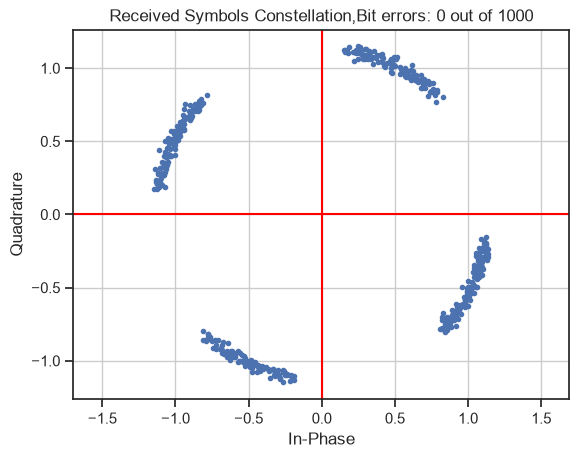

Detection Threshold,0.3,Detection UseNorm True


In [9]:
## matched filter output
# we need a different pulse than the transmitter because the oversampling factor is different
DEBUG=True
mf_hh = SqrtRaisedCosinePulse(num_samples=10*fsT_r, oversamp=fsT_r, alpha=0.5)._generate_samples()
mf_out = np.convolve(rr, np.flipud(mf_hh.conj()))



# Suggested options
# detection_useNorm=False
# detection_threshold=215
#
detection_useNorm=True
detection_threshold=.3
rx=Receiver(preamble_symbols,fsT_r,GenericSlicer(payload_constellation),detection_threshold=detection_threshold,detection_useNorm=detection_useNorm)

results=rx.process(mf_out,500)

#Check detection results
received_preamble_buffer=results['received_preamble_buffer']
p_ind=results['p_ind']
k_ind=results['k_ind']
corr_val=results['corr_val']
mode=results['detected']

if DEBUG is True:
    print("\n" + "=" * 60)
    print(f"--- Peak Correlation Results ---")
    print(f"Absolute Max Magnitude: {np.abs(corr_val):.4f}")
    print(f"Best Sampling Phase (p_ind): {p_ind}")
    print(f"Best Symbol Index (k_ind):    {k_ind}")
    print(f"Complex Value at Peak:        {corr_val}")

    print("\n")
    print("idx received sample expected error angle")
    print("idx received sample expected error angle(rad)")
    for i, (r, p) in enumerate(zip(received_preamble_buffer[:10],
        preamble_symbols[:10])):
        error = int(np.sign(r.real) != np.sign(p.real))
        angle=np.angle(r)
        print(
        f"{i:2d} "
        f"{r.real:8.4f}{r.imag:+8.4f}j "
        f"{p.real:.0f}{p.imag:+.0f}j "
        f"{error:5d}"
        f"{angle:10.2f}"
    )

    #print(f"length received_preamble_buffer",len(received_preamble_buffer))
    #print(f"angles",np.angle(received_preamble_buffer[:5]))
    print("\n" + "=" * 60)





#print(f"[DEBUG]length received_preamble_buffer",len(received_preamble_buffer))


#Check estimation results
corrected_symbols = results['demod_samples_corrected']
#print(f"[DEBUG] len(corrected_symbols),{len(corrected_symbols)}")

#Slicer 
N_bits=len(payload_bits)
rx_bits= results['bits']
BER=np.sum(payload_bits != rx_bits)/N_bits

if DEBUG is True:
    print(f"bit errors: {np.sum(payload_bits != rx_bits)} out of {N_bits}")

plt.plot(np.real(corrected_symbols), np.imag(corrected_symbols), '.b')
#plt.plot(np.real(corrected_symbols[:20]), np.imag(corrected_symbols[:20]), '.b')
plt.xlabel('In-Phase')
plt.ylabel('Quadrature')
plt.title(f"Received Symbols Constellation,Bit errors: {np.sum(payload_bits != rx_bits)} out of {N_bits}")
plt.grid(True)
plt.axis('equal')
# plt.xlim(-1.5,1.5)
# plt.ylim(-1.5,1.5)
plt.axhline(0, color='red', linewidth=1.5)
plt.axvline(0, color='red', linewidth=1.5)    
plt.show()


print(f"Detection Threshold,{detection_threshold},Detection UseNorm {detection_useNorm}")
#print(f"bit errors: {np.sum(payload_bits[:20] != rx_bits[:20])} out of {20}")
#print(f"Phasor,{results['phasor']}")




In [10]:
# tmp=results['received_preamble_buffer']*np.conj(preamble_symbols)
# plt.plot(np.angle(tmp,'deg'))
